In [1]:
from random import *
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import pandas as pd
import numpy.ma as ma
import pickle
import seaborn as sns
from scipy.io import loadmat
import sys
import pathlib
import itertools
import re
import platform
from rpy2 import robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.packages import importr
import rpy2.ipython.html
from collections import defaultdict
import ast
# from statannotations.Annotator import Annotator
from scipy.stats import mannwhitneyu, normaltest, page_trend_test
# from utils import *
# from statannotations.stats.StatTest import StatTest
# Set a white background for the entire figure
plt.rcParams['axes.facecolor'] = 'white'
# Set a high DPI for high-quality images
plt.rcParams['figure.dpi'] = 300

# General plot settings for publication
plt.rcParams.update({
    'font.size': 20,          # General font size
    'axes.titlesize': 22,     # Title font size
    'axes.labelsize': 20,     # Axis label font size
    'xtick.labelsize': 20,    # X-axis tick font size
    'ytick.labelsize': 20,    # Y-axis tick font size
    'legend.fontsize': 20,    # Legend font size
    'figure.figsize': (8, 6) # Default figure size
})


In [2]:
%load_ext rpy2.ipython

In [3]:
%%R

library(lmerTest)
library(broom.mixed)
library(dplyr)
library(kableExtra)
library(BayesFactor)


R[write to console]: Loading required package: lme4

R[write to console]: Loading required package: Matrix

R[write to console]: 
Attaching package: ‘lmerTest’


R[write to console]: The following object is masked from ‘package:lme4’:

    lmer


R[write to console]: The following object is masked from ‘package:stats’:

    step


R[write to console]: 
Attaching package: ‘dplyr’


R[write to console]: The following objects are masked from ‘package:stats’:

    filter, lag


R[write to console]: The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


R[write to console]: 
Attaching package: ‘kableExtra’


R[write to console]: The following object is masked from ‘package:dplyr’:

    group_rows


R[write to console]: Loading required package: coda

R[write to console]: ************
Welcome to BayesFactor 0.9.12-4.7. If you have questions, please contact Richard Morey (richarddmorey@gmail.com).

Type BFManual() to open the manual.
************



In [4]:
import os
import pandas as pd
import platform

if platform.system() == "Windows":
    wanted_dir = "/data/sourcedata/behavior/modified_files"
else:
    wanted_dir = "/Volumes/SDrive/data/sourcedata/behavior/modified_files"

# Create the subject list with exclusions
subject_list = range(1, 65)
excluded_subjects = [8, 13, 16, 31, 32, 44]
subject_list = [str(sub).zfill(2) for sub in subject_list if sub not in excluded_subjects]

subject_valid = []

def create_combined_dataframe_with_files(wanted_dir, subject_list):
    # Get all files in the directory matching the criteria
    file_list = [
        os.path.join(root, name)
        for root, dirs, files in os.walk(wanted_dir)
        for name in files
        if name.endswith('savedValues.csv') and not name.startswith("._")
    ]

    # Filter files based on "participantXX" in filenames
    filtered_file_list = [
        file for file in file_list
        if any(f"participant{sub}" in file for sub in subject_list)
    ]

    # Combine all remaining files into a single DataFrame, assigning subject as i
    files = []
    combined_data = []  # Using a list to hold individual DataFrames initially
    i = 0

    for file in filtered_file_list:
        data = pd.read_csv(file)
        subject_id = file.split("/")[-1].split("participant")[-1][:2]  # Extract subject ID
        if max(data['runNumber']) == 6:  # Only include files with exactly 6 runs
            i += 1
            subject_valid.append(int(subject_id))
            data['subject'] = i  # Assign subject as i
            data = data.set_index(['trialNumber', 'runNumber', 'subject'])  # Set the indices with trialNumber first
            combined_data.append(data)
            files.append(file)

    if not combined_data:
        return [], pd.DataFrame(), []

    combined_data = pd.concat(combined_data)
    return files, combined_data, subject_valid

# Create the combined DataFrame and get the valid files
files, df, subject_valid = create_combined_dataframe_with_files(wanted_dir, subject_list)

# Output summary
print(f"Valid files combined: {len(files)}")
print(f"Subjects included: {subject_valid}")


Valid files combined: 58
Subjects included: [1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 14, 15, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64]


In [5]:
import os
import pandas as pd
import numpy as np
from scipy.io import loadmat   # <-- ADD THIS LINE

# Initialize lists to store data
spes = []
rpes = []
V0s = []
V1s = []

for subject in subject_valid:
    subject_path = f'/Volumes/SDrive/data/fittedParameters/sub-{subject:02d}/'
    
    try:
        # Load spe.npy
        spe_file = next((f for f in os.listdir(subject_path) if f.startswith('spe') and f.endswith('.npy')), None)
        if spe_file:
            spe = np.load(os.path.join(subject_path, spe_file))
            spe = pd.DataFrame(
                spe,
                columns=pd.Index(np.arange(1, 61), name='trialNumber'),
                index=pd.Index(np.arange(1, 7), name='runNumber')
            )
            spe = spe.stack().to_frame('spe')
            spes.append(spe)
        else:
            print(f"No spe file found for subject {subject}")

        # Load rpeBest.mat (rpe)
        rpe = loadmat(os.path.join(subject_path, 'rpeBest.mat'), simplify_cells=True)['rpe']['rpe']
        rpe = pd.DataFrame(
            rpe,
            columns=pd.Index(np.arange(1, 61), name='trialNumber'),
            index=pd.Index(np.arange(1, 7), name='runNumber')
        )
        rpe = rpe.stack().to_frame('rpe')
        rpes.append(rpe)

        # Dynamically detect V0 and V1 files
        files = os.listdir(subject_path)
        V0_file = next((f for f in files if f.startswith('V0_') and f.endswith('.npy')), None)
        V1_file = next((f for f in files if f.startswith('V1_') and f.endswith('.npy')), None)

        # Load V0.npy
        if V0_file:
            V0 = np.load(os.path.join(subject_path, V0_file))
            V0 = pd.DataFrame(
                V0,
                columns=pd.Index(np.arange(1, 61), name='trialNumber'),
                index=pd.Index(np.arange(1, 7), name='runNumber')
            )
            V0 = V0.stack().to_frame('V0')
            V0s.append(V0)
        else:
            print(f"No V0 file found for subject {subject}")

        # Load V1.npy
        if V1_file:
            V1 = np.load(os.path.join(subject_path, V1_file))
            V1 = pd.DataFrame(
                V1,
                columns=pd.Index(np.arange(1, 61), name='trialNumber'),
                index=pd.Index(np.arange(1, 7), name='runNumber')
            )
            V1 = V1.stack().to_frame('V1')
            V1s.append(V1)
        else:
            print(f"No V1 file found for subject {subject}")

    except Exception as e:
        print(f'There was a problem with subject {subject}:\n{e}')

# Concatenate DataFrames for each type
if spes:
    spes = pd.concat(spes, keys=subject_valid, names=['subject'])
if rpes:
    rpes = pd.concat(rpes, keys=subject_valid, names=['subject'])
if V0s:
    V0s = pd.concat(V0s, keys=subject_valid, names=['subject'])
if V1s:
    V1s = pd.concat(V1s, keys=subject_valid, names=['subject'])

# Join all columns to the main df
if 'spes' in locals():
    df = df.join(spes, how='left')
if 'rpes' in locals():
    df = df.join(rpes, how='left')
if 'V0s' in locals():
    df = df.join(V0s, how='left')
if 'V1s' in locals():
    df = df.join(V1s, how='left')

# Create the 'Vchosen' column based on the 'action' column in df
df['Vchosen'] = np.where(df['action'] == 0.0, df['V0'], 
                         np.where(df['action'] == 1.0, df['V1'], np.nan))

# Create the 'Vunchosen' column based on the 'action' column in df
df['Vunchosen'] = np.where(df['action'] == 0.0, df['V1'], 
                           np.where(df['action'] == 1.0, df['V0'], np.nan))

# Calculate absolute difference between V0 and V1
df['Vdiff'] = np.abs(df['V0'] - df['V1'])
df['Vsum'] = df['V0'] + df['V1']

# Create the 'audiovisual' column based on whether 'audio' or 'tactile' is NaN
df['audiovisual'] = np.where(df['audio'].notna(), 1,
                             np.where(df['tactile'].notna(), 0, np.nan))


In [6]:
df

,,,visualSet,audioPair_1,audioPair_2,audioPair_3,tactilePair_1,tactilePair_2,tactilePair_3,visual,audio,tactile,...,stimulusPair,spe,rpe,V0,V1,Vchosen,Vunchosen,Vdiff,Vsum,audiovisual
trialNumber,runNumber,subject,,,,,,,,,,,,,,,,,,,,,
1,1,1,0,1,0,2,0,1,2,0,NaN,2.0,...,"(0, 2)",2.197225,-0.500000,0.500000,0.500000,0.500000,0.500000,0.000000,1.000000,0.0
2,1,1,0,1,0,2,0,1,2,1,NaN,1.0,...,"(1, 1)",2.302585,-0.500000,0.500000,0.500000,0.500000,0.500000,0.000000,1.000000,0.0
3,1,1,0,1,0,2,0,1,2,2,NaN,2.0,...,"(2, 2)",2.397895,0.500000,0.500000,0.500000,0.500000,0.500000,0.000000,1.000000,0.0
4,1,1,0,1,0,2,0,1,2,0,NaN,0.0,...,"(0, 0)",2.484907,-0.500000,0.500000,0.500000,0.500000,0.500000,0.000000,1.000000,0.0
5,1,1,0,1,0,2,0,1,2,2,NaN,1.0,...,"(2, 1)",2.564949,0.500000,0.500000,0.500000,0.500000,0.500000,0.000000,1.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,6,58,5,2,0,1,1,2,0,0,1.0,NaN,...,"(0, 1)",3.060271,0.413813,0.469979,0.586187,0.586187,0.469979,0.116208,1.056167,1.0
57,6,58,5,2,0,1,1,2,0,1,0.0,NaN,...,"(1, 0)",1.977163,-0.657518,0.657518,0.540734,0.657518,0.540734,0.116784,1.198252,1.0
58,6,58,5,2,0,1,1,2,0,2,2.0,NaN,...,"(2, 2)",1.887070,0.382373,0.617627,0.457585,0.457585,0.617627,0.160042,1.075212,1.0


In [7]:
audio_runs = df[np.isnan(df['tactile'])]  # Example adjustments
tactile_runs = df[np.isnan(df['audio'])]  # Example adjustments

In [8]:
import numpy as np
import pandas as pd

# ---- Audiovisual condition ----
# Each subject’s mean accuracy per trial
audio_subject_trial = audio_runs.groupby(['subject', 'trialNumber'])['accurate'].mean().reset_index()

# Then, compute group-level mean and SEM across subjects for each trial
audio_summary = audio_subject_trial.groupby('trialNumber')['accurate'].agg(
    mean='mean',
    sem=lambda x: x.std(ddof=1) / np.sqrt(len(x))
)

# ---- Visuotactile condition ----
tactile_subject_trial = tactile_runs.groupby(['subject', 'trialNumber'])['accurate'].mean().reset_index()
tactile_summary = tactile_subject_trial.groupby('trialNumber')['accurate'].agg(
    mean='mean',
    sem=lambda x: x.std(ddof=1) / np.sqrt(len(x))
)


# Fig 1a - Performance

In [9]:
def ma(interval, window_size, method):
    window = np.ones(int(window_size))/float(window_size)
    return np.convolve(interval, window, method)

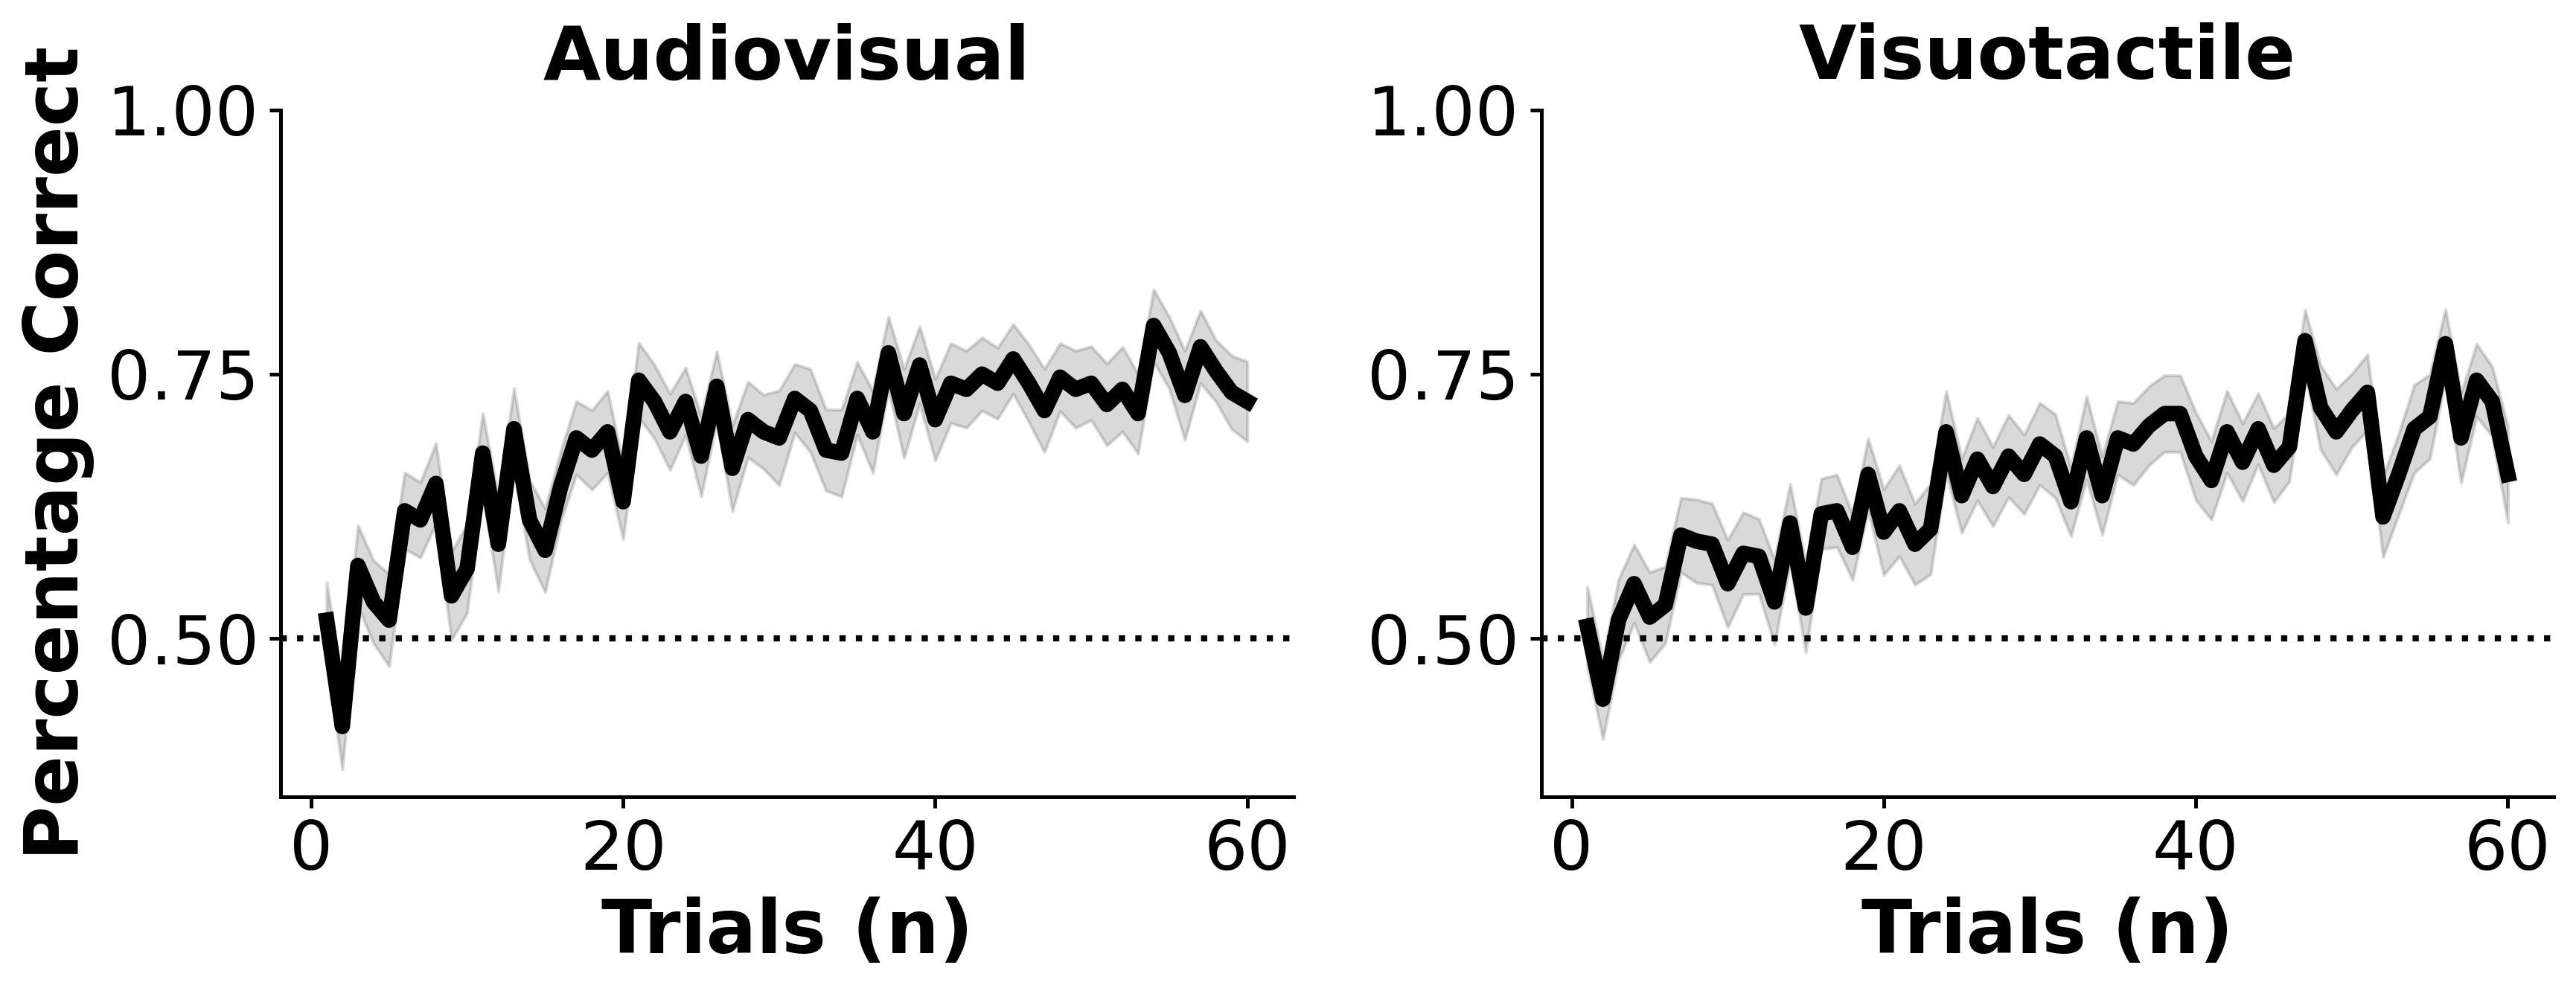

In [10]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 22,
    'axes.titlesize': 24,
    'axes.labelsize': 24,
    'xtick.labelsize': 22,
    'ytick.labelsize': 22,
    'legend.fontsize': 20,
    'figure.figsize': (12, 5)
})

fig, axes = plt.subplots(1, 2, sharey=False)

# ---------- Audiovisual ----------
axes[0].plot(audio_summary.index, audio_summary['mean'],
             color='black', linewidth=5)
axes[0].fill_between(audio_summary.index,
                     audio_summary['mean'] - audio_summary['sem'],
                     audio_summary['mean'] + audio_summary['sem'],
                     color='black', alpha=0.15)

# --- Reference line at 0.5 ---
axes[0].axhline(y=0.5, color='black', linestyle=':', linewidth=2)

axes[0].set_title("Audiovisual", weight='bold', pad=10)
axes[0].set_xlabel("Trials (n)", weight='bold')
axes[0].set_ylabel("Percentage Correct", weight='bold')
axes[0].set_ylim(0.35, 1)
axes[0].set_yticks([0.5, 0.75, 1.0])  # ✅ Simplified y-ticks
axes[0].grid(False)

# ---------- Visuotactile ----------
axes[1].plot(tactile_summary.index, tactile_summary['mean'],
             color='black', linewidth=5)
axes[1].fill_between(tactile_summary.index,
                     tactile_summary['mean'] - tactile_summary['sem'],
                     tactile_summary['mean'] + tactile_summary['sem'],
                     color='black', alpha=0.15)

# --- Reference line at 0.5 ---
axes[1].axhline(y=0.5, color='black', linestyle=':', linewidth=2)

axes[1].set_title("Visuotactile", weight='bold', pad=10)
axes[1].set_xlabel("Trials (n)", weight='bold')
axes[1].set_ylim(0.35, 1)
axes[1].set_yticks([0.5, 0.75, 1.0])  # ✅ Same tick spacing
axes[1].grid(False)

# ---------- Despine & Styling ----------
for ax in axes:
    ax.tick_params(axis='both', labelsize=22, width=1.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)

plt.tight_layout(rect=[0, 0, 1, 0.98])

# ---------- Save ----------
save_path = "/Users/sbedi/Desktop/work in progress/multisensoryLearning/figurePDFs/Fig2/performance_side_by_side.pdf"
plt.savefig(save_path, format='pdf')
plt.show()


In [11]:
glm_df = df.reset_index()

In [12]:
glm_df

,trialNumber,runNumber,subject,visualSet,audioPair_1,audioPair_2,audioPair_3,tactilePair_1,tactilePair_2,tactilePair_3,...,stimulusPair,spe,rpe,V0,V1,Vchosen,Vunchosen,Vdiff,Vsum,audiovisual
0,1,1,1,0,1,0,2,0,1,2,...,"(0, 2)",2.197225,-0.500000,0.500000,0.500000,0.500000,0.500000,0.000000,1.000000,0.0
1,2,1,1,0,1,0,2,0,1,2,...,"(1, 1)",2.302585,-0.500000,0.500000,0.500000,0.500000,0.500000,0.000000,1.000000,0.0
2,3,1,1,0,1,0,2,0,1,2,...,"(2, 2)",2.397895,0.500000,0.500000,0.500000,0.500000,0.500000,0.000000,1.000000,0.0
3,4,1,1,0,1,0,2,0,1,2,...,"(0, 0)",2.484907,-0.500000,0.500000,0.500000,0.500000,0.500000,0.000000,1.000000,0.0
4,5,1,1,0,1,0,2,0,1,2,...,"(2, 1)",2.564949,0.500000,0.500000,0.500000,0.500000,0.500000,0.000000,1.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20875,56,6,58,5,2,0,1,1,2,0,...,"(0, 1)",3.060271,0.413813,0.469979,0.586187,0.586187,0.469979,0.116208,1.056167,1.0
20876,57,6,58,5,2,0,1,1,2,0,...,"(1, 0)",1.977163,-0.657518,0.657518,0.540734,0.657518,0.540734,0.116784,1.198252,1.0
20877,58,6,58,5,2,0,1,1,2,0,...,"(2, 2)",1.887070,0.382373,0.617627,0.457585,0.457585,0.617627,0.160042,1.075212,1.0
20878,59,6,58,5,2,0,1,1,2,0,...,"(1, 1)",1.902108,0.381960,0.618040,0.540734,0.540734,0.618040,0.077306,1.158774,1.0


In [13]:
%%R -i glm_df -o df_model

# Mixed-effects model for audio runs
# Fit the mixed-effects model
df_model <- lmerTest::lmer(responseTime ~ 1 + spe*audiovisual  + Vchosen + Vunchosen  + audiovisual + (1 | subject), data = glm_df)

# Summarize the model results
summary(df_model)


Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: responseTime ~ 1 + spe * audiovisual + Vchosen + Vunchosen +  
    audiovisual + (1 | subject)
   Data: glm_df

REML criterion at convergence: 17081.4

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.6193 -0.6418 -0.0471  0.6083  4.5543 

Random effects:
 Groups   Name        Variance Std.Dev.
 subject  (Intercept) 0.04462  0.2112  
 Residual             0.14487  0.3806  
Number of obs: 18544, groups:  subject, 52

Fixed effects:
                  Estimate Std. Error         df t value Pr(>|t|)    
(Intercept)      1.962e+00  3.978e-02  1.698e+02  49.326  < 2e-16 ***
spe              1.692e-02  1.022e-02  1.849e+04   1.657   0.0976 .  
audiovisual     -3.291e-01  3.283e-02  1.849e+04 -10.026  < 2e-16 ***
Vchosen         -9.706e-02  1.362e-02  1.852e+04  -7.127 1.06e-12 ***
Vunchosen       -5.815e-02  1.410e-02  1.851e+04  -4.123 3.75e-05 ***
spe:audiovisual  5.949e-03  1.437e-0

## Fig1b - Surprise GLM

In [14]:
glm_audio = audio_runs.reset_index()
glm_tactile = tactile_runs.reset_index()

In [15]:
%%R -i glm_audio -o glm_audio

# Mixed-effects model for audio runs
# Fit the mixed-effects model
audio_model <- lmerTest::lmer(responseTime ~ 1 + spe + Vchosen + Vunchosen  + (1 | subject), data = glm_audio)

# Summarize the model results
summary(audio_model)


Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: responseTime ~ 1 + spe + Vchosen + Vunchosen + (1 | subject)
   Data: glm_audio

REML criterion at convergence: 8680.5

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.8113 -0.6848 -0.0753  0.5940  4.5735 

Random effects:
 Groups   Name        Variance Std.Dev.
 subject  (Intercept) 0.05022  0.2241  
 Residual             0.14528  0.3812  
Number of obs: 9292, groups:  subject, 52

Fixed effects:
              Estimate Std. Error         df t value Pr(>|t|)    
(Intercept)    1.62497    0.04335  185.61150  37.488  < 2e-16 ***
spe            0.02277    0.01021 9237.63203   2.230   0.0258 *  
Vchosen       -0.10555    0.01968 9271.57851  -5.364 8.34e-08 ***
Vunchosen     -0.03247    0.02031 9269.77373  -1.599   0.1099    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
          (Intr) spe    Vchosn
spe       -0.569              

In [16]:

%%R -i glm_tactile -o glm_tactile

# Mixed-effects model for tactile runs
# Fit the mixed-effects model
tactile_model <- lmerTest::lmer(responseTime ~ 1 + spe + Vchosen + Vunchosen + (1 | subject), data = glm_tactile)

# Summarize the model results
summary(tactile_model)


Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: responseTime ~ 1 + spe + Vchosen + Vunchosen + (1 | subject)
   Data: glm_tactile

REML criterion at convergence: 7749.4

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.4576 -0.5856 -0.0247  0.6033  3.8793 

Random effects:
 Groups   Name        Variance Std.Dev.
 subject  (Intercept) 0.05182  0.2276  
 Residual             0.13180  0.3630  
Number of obs: 9252, groups:  subject, 52

Fixed effects:
              Estimate Std. Error         df t value Pr(>|t|)    
(Intercept)  1.960e+00  4.286e-02  1.674e+02  45.731  < 2e-16 ***
spe          1.743e-02  9.778e-03  9.198e+03   1.782 0.074750 .  
Vchosen     -8.142e-02  1.857e-02  9.229e+03  -4.384 1.18e-05 ***
Vunchosen   -7.275e-02  1.920e-02  9.223e+03  -3.789 0.000152 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
          (Intr) spe    Vchosn
spe       -0.554            

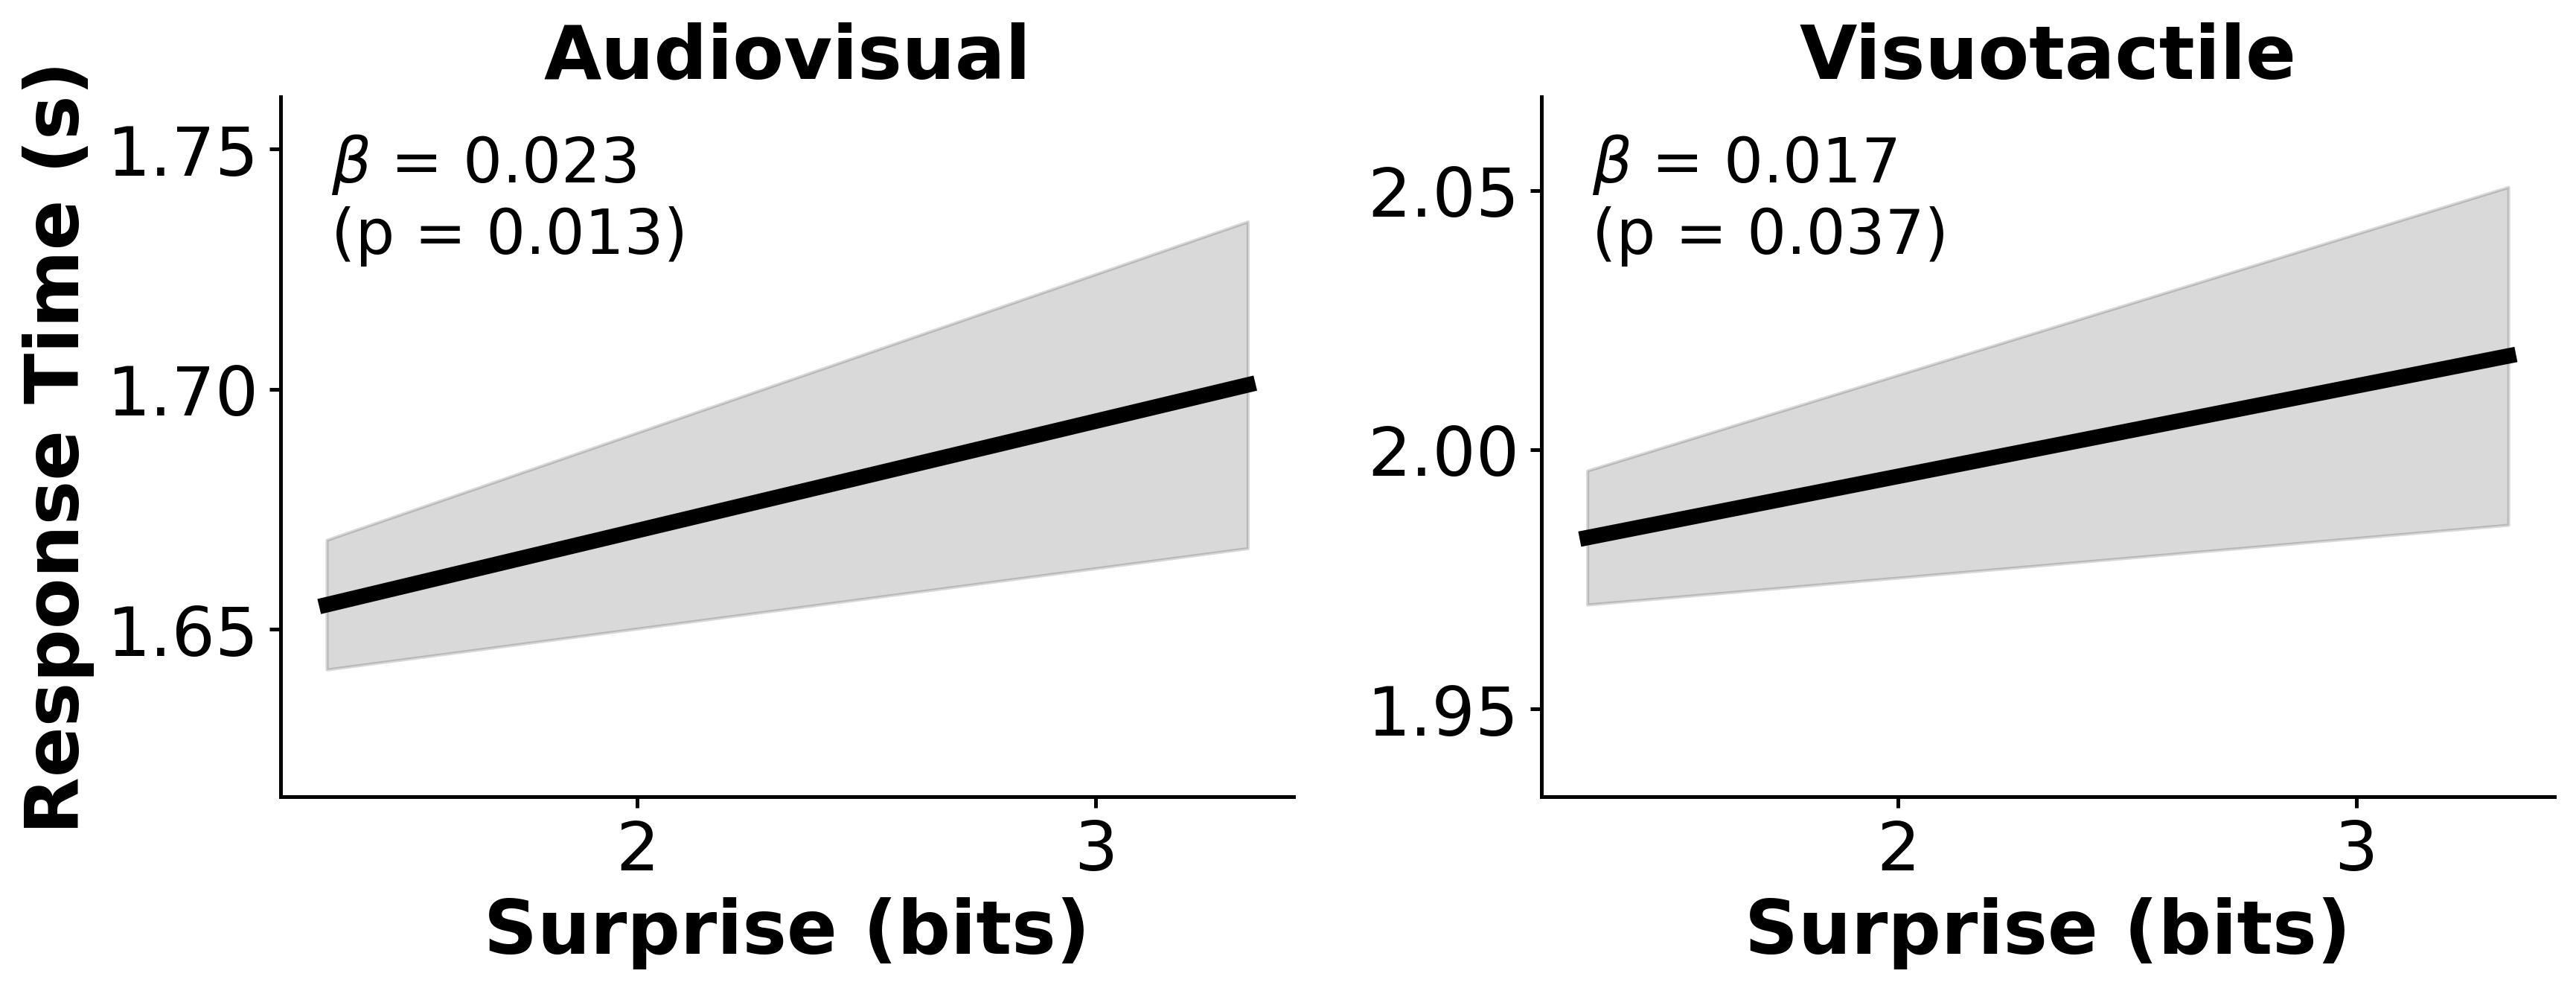

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# --- Parameters and one-sided p values ---
audio_intercept = 1.625
audio_spe_coef = 0.02277
audio_spe_se   = 0.01021
audio_pval_1s  = 0.0258 / 2   # 0.0129

tactile_intercept = 1.960
tactile_spe_coef = 0.01743
tactile_spe_se   = 0.00978
tactile_pval_1s  = 0.07475 / 2   # 0.0374

# Shared SPE range
spe_range = np.linspace(spe_min, spe_max, 200)

# --- Formatting parameters (matching learning curves) ---
plt.rcParams.update({
    'font.size': 22,
    'axes.titlesize': 24,
    'axes.labelsize': 24,
    'xtick.labelsize': 22,
    'ytick.labelsize': 22,
    'figure.figsize': (12, 5)
})

fig, axes = plt.subplots(1, 2, sharey=False)

# -------------------------------------------------
#  AUDIOVISUAL PANEL
# -------------------------------------------------
ax = axes[0]
audio_pred = audio_intercept + audio_spe_coef * spe_range
audio_err  = audio_spe_se * np.abs(spe_range)

ax.plot(spe_range, audio_pred, color='black', linewidth=5)
ax.fill_between(spe_range,
                audio_pred - audio_err,
                audio_pred + audio_err,
                color='black', alpha=0.15)

ax.set_title("Audiovisual", weight="bold")
ax.set_xlabel("Surprise (bits)", weight="bold")
ax.set_ylabel("Response Time (s)", weight="bold")
ax.set_ylim(audio_pred.min() - 0.04, audio_pred.max() + 0.06)

# Inline text (top left corner)
audio_text = f"$\\beta$ = {audio_spe_coef:.3f}\n(p = {audio_pval_1s:.3f})"
ax.text(0.05, 0.95, audio_text,
        transform=ax.transAxes,
        fontsize=20, va='top', ha='left', color='black')

# -------------------------------------------------
#  VISUO-TACTILE PANEL
# -------------------------------------------------
ax = axes[1]
tactile_pred = tactile_intercept + tactile_spe_coef * spe_range
tactile_err  = tactile_spe_se * np.abs(spe_range)

ax.plot(spe_range, tactile_pred, color='black', linewidth=5, linestyle='-')
ax.fill_between(spe_range,
                tactile_pred - tactile_err,
                tactile_pred + tactile_err,
                color='black', alpha=0.15)

ax.set_title("Visuotactile", weight="bold")
ax.set_xlabel("Surprise (bits)", weight="bold")
ax.set_ylim(tactile_pred.min() - 0.05, tactile_pred.max() + 0.05)

# Inline text (top left corner)
tactile_text = f"$\\beta$ = {tactile_spe_coef:.3f}\n(p = {tactile_pval_1s:.3f})"
ax.text(0.05, 0.95, tactile_text,
        transform=ax.transAxes,
        fontsize=20, va='top', ha='left', color='black')

# -------------------------------------------------
#  Despine & Styling
# -------------------------------------------------
for ax in axes:
    ax.tick_params(axis='both', labelsize=22, width=1.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)

    # Format y-axis ticks to 2 decimals
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}'))

plt.tight_layout(rect=[0, 0, 1, 0.98])

# ---------- Save ----------
save_path = "/Users/sbedi/Desktop/work in progress/multisensoryLearning/figurePDFs/Fig2/RT_spe_fits.pdf"
plt.savefig(save_path, format="pdf")
plt.show()


## Correlation between spe and rpe

------------------------------------------------------------
RPE–SPE Subject-level Correlation Summary
------------------------------------------------------------
 subject  mean_r      z
       1   0.057  0.057
       2   0.165  0.166
       3   0.093  0.094
       4   0.105  0.105
       5   0.025  0.025
       6   0.105  0.106
       7  -0.019 -0.019
       9   0.127  0.127
      10   0.093  0.094
      11   0.049  0.049
      12  -0.018 -0.018
      14   0.065  0.065
      15  -0.033 -0.033
      17  -0.016 -0.016
      18  -0.139 -0.139
      19   0.010  0.010
      20   0.048  0.048
      21   0.050  0.050
      22   0.032  0.032
      23  -0.055 -0.055
      24   0.152  0.153
      25   0.133  0.134
      26  -0.072 -0.072
      27  -0.013 -0.013
      28  -0.079 -0.079
      29   0.005  0.005
      30   0.078  0.078
      33   0.153  0.154
      34   0.019  0.019
      35  -0.141 -0.141
      36   0.012  0.012
      37  -0.056 -0.056
      38  -0.054 -0.054
      39   0.069  0.

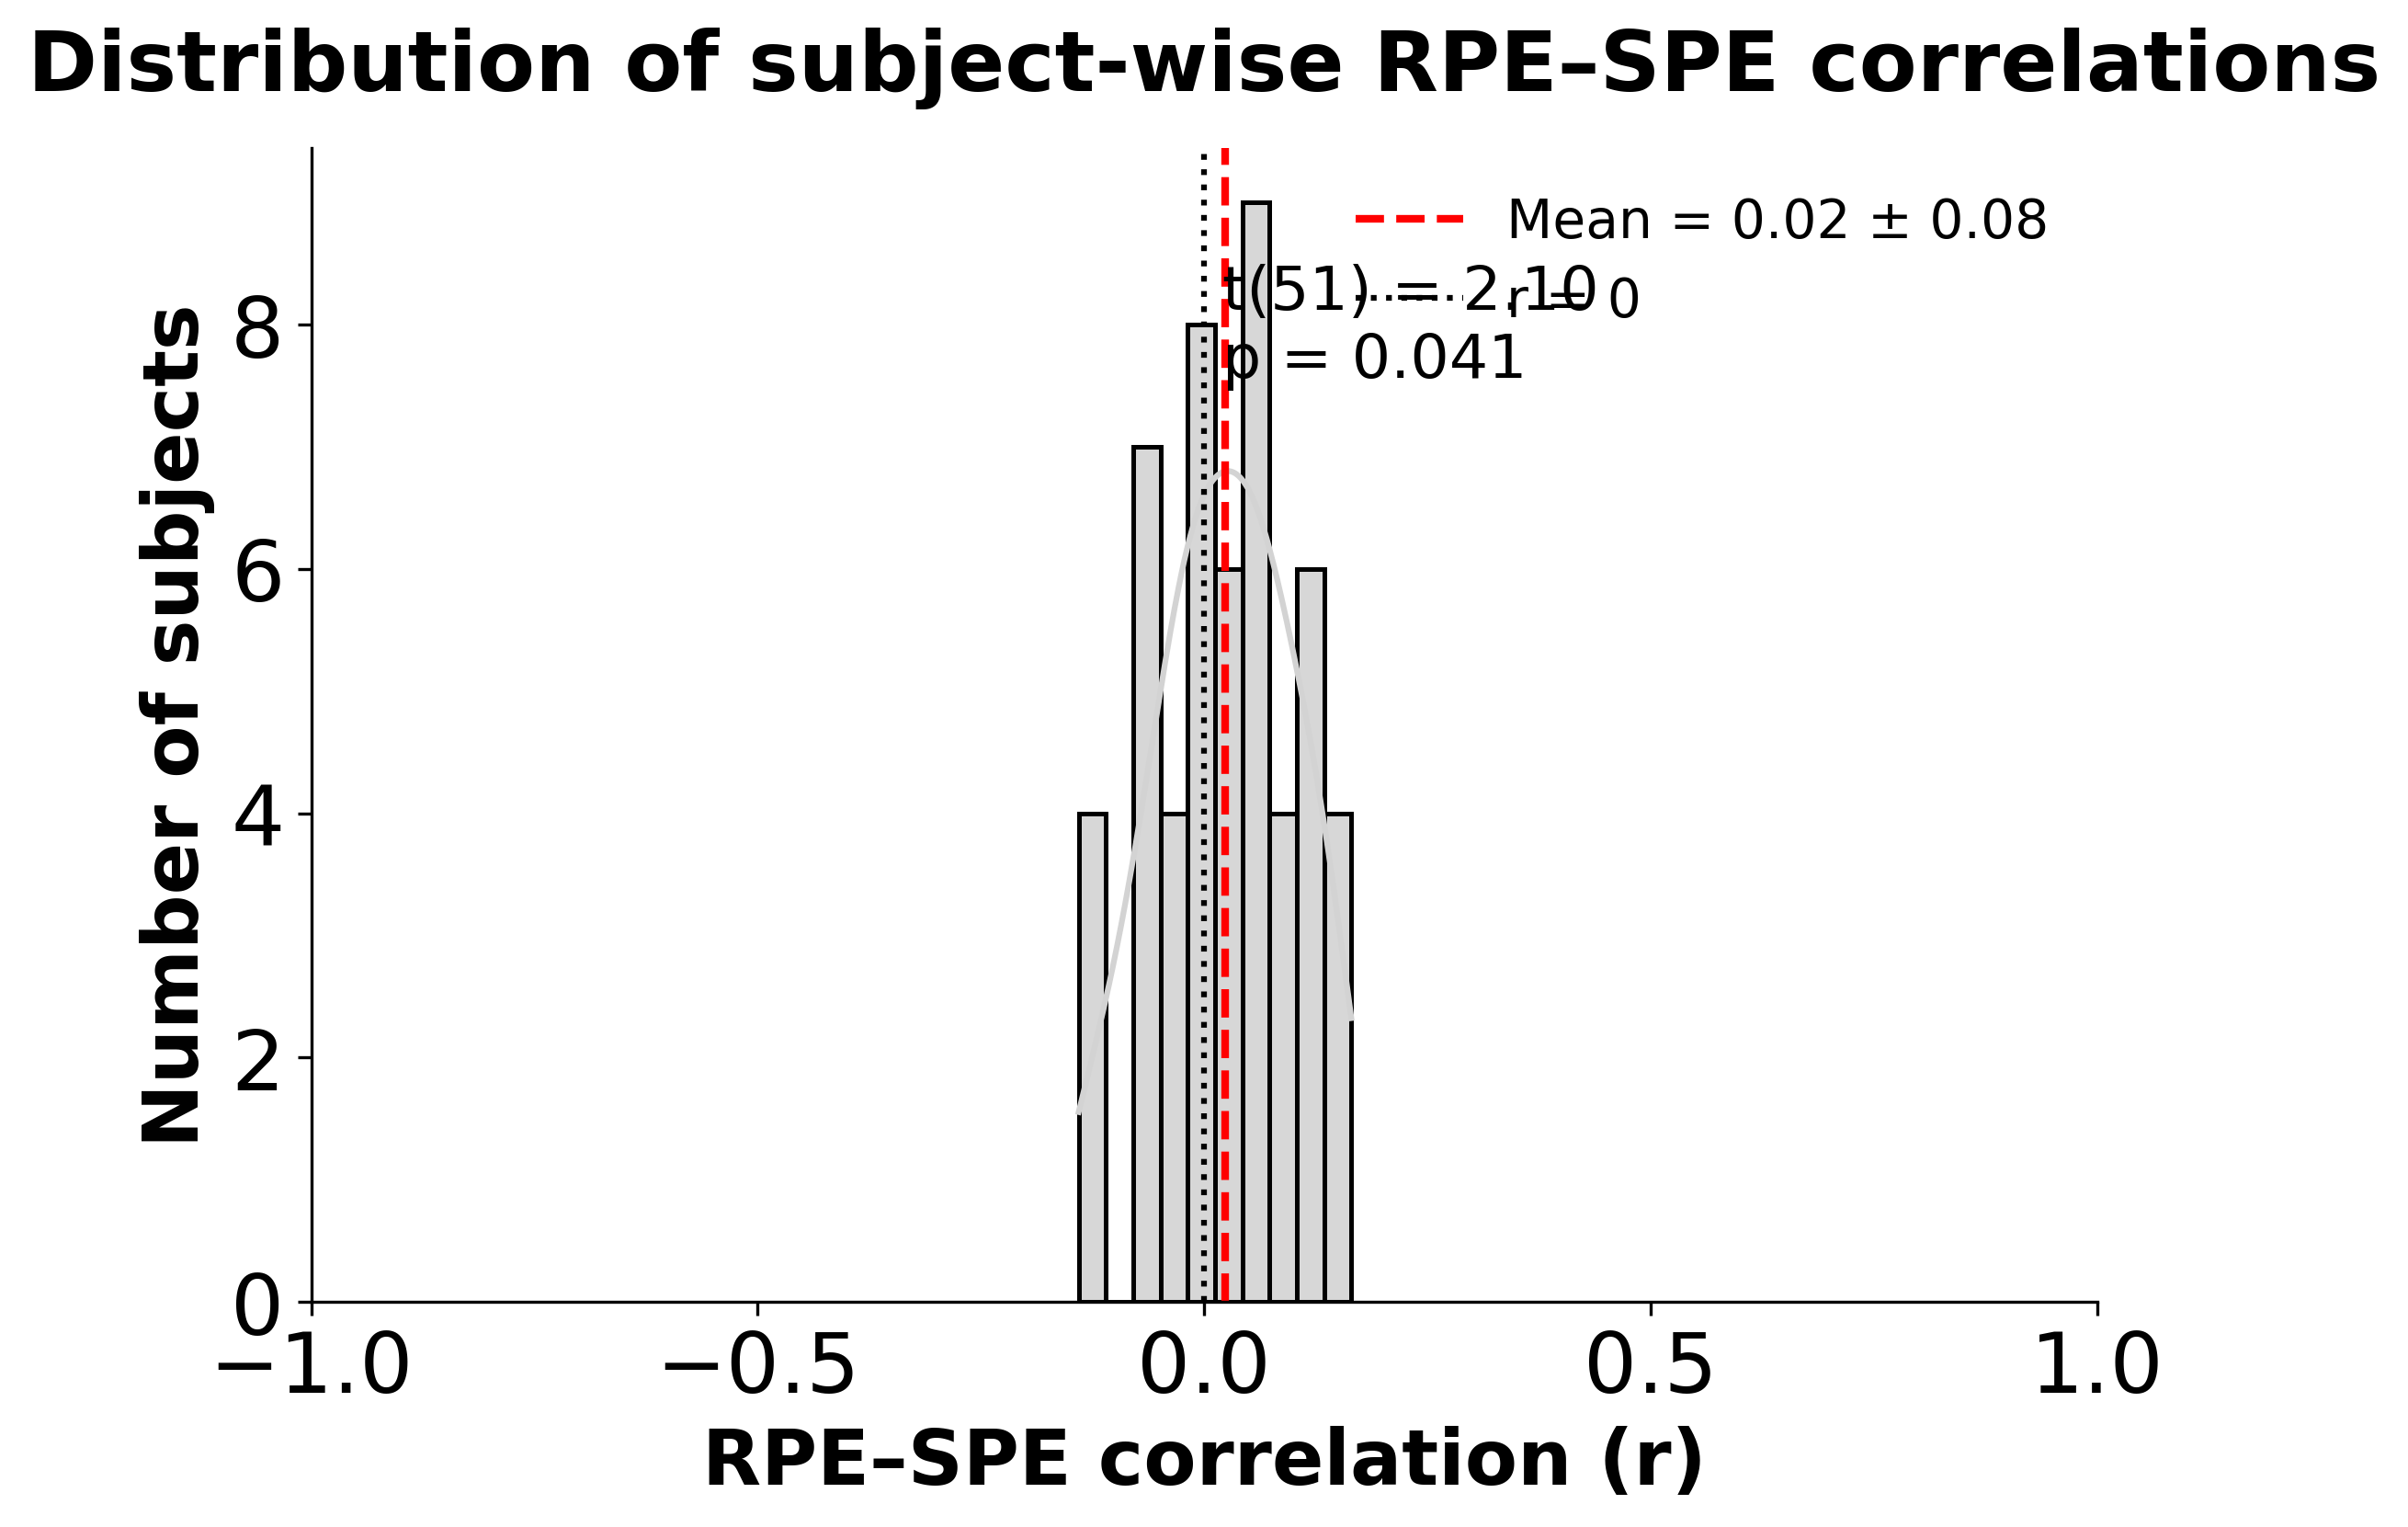

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_1samp

# ------------------------------------------------------------
# 1. Compute per-subject mean RPE–SPE correlation
# ------------------------------------------------------------
subject_corrs = []

for subject in subject_valid:
    run_corrs = []
    for run in range(1, 7):
        subset = df.loc[
            (df.index.get_level_values('subject') == subject) &
            (df.index.get_level_values('runNumber') == run)
        ]
        if subset.empty:
            continue
        spe_vals = subset['spe'].to_numpy()
        rpe_vals = subset['rpe'].to_numpy()
        valid_mask = ~np.isnan(spe_vals) & ~np.isnan(rpe_vals)
        if np.sum(valid_mask) > 1:
            r = np.corrcoef(spe_vals[valid_mask], rpe_vals[valid_mask])[0, 1]
            run_corrs.append(r)
    if run_corrs:
        subject_corrs.append({
            "subject": subject,
            "mean_r": np.nanmean(run_corrs)
        })

corr_df = pd.DataFrame(subject_corrs)
corr_df["z"] = np.arctanh(corr_df["mean_r"])  # Fisher z transform

# ------------------------------------------------------------
# 2. One-sample t-test on Fisher z values (H0: mean = 0)
# ------------------------------------------------------------
t_stat, p_val = ttest_1samp(corr_df["z"], 0, nan_policy='omit')
mean_z = np.nanmean(corr_df["z"])
mean_r = np.tanh(mean_z)
std_r = np.nanstd(corr_df["mean_r"])
n = len(corr_df)

# ------------------------------------------------------------
# 3. Print summary stats
# ------------------------------------------------------------
print("------------------------------------------------------------")
print("RPE–SPE Subject-level Correlation Summary")
print("------------------------------------------------------------")
print(corr_df.to_string(index=False, float_format="%.3f"))
print("------------------------------------------------------------")
print(f"Subjects included: {n}")
print(f"Mean correlation (r): {mean_r:.3f} ± {std_r:.3f}")
print(f"T({n - 1}) = {t_stat:.2f}, p = {p_val:.4f}")
if p_val < 0.05:
    print("→ Mean correlation significantly different from 0.")
else:
    print("→ Mean correlation not significantly different from 0 (ns).")
print("------------------------------------------------------------")

# ------------------------------------------------------------
# 4. Publication-quality histogram
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.histplot(
    corr_df["mean_r"], bins=10, kde=True,
    color='lightgray', edgecolor='black', linewidth=1.2, alpha=0.9
)

plt.axvline(mean_r, color='red', linestyle='--', linewidth=2,
            label=f"Mean = {mean_r:.2f} ± {std_r:.2f}")
plt.axvline(0, color='black', linestyle=':', linewidth=1.5, label='r = 0')

plt.xlabel("RPE–SPE correlation (r)", fontsize=20, weight='bold')
plt.ylabel("Number of subjects", fontsize=20, weight='bold')
plt.title("Distribution of subject-wise RPE–SPE correlations", fontsize=22, weight='bold', pad=15)
plt.legend(fontsize=14, frameon=False)
plt.xlim(-1, 1)

plt.text(0.02, plt.ylim()[1]*0.9,
         f"t({n-1}) = {t_stat:.2f}\n"
         f"p = {p_val:.3f}",
         fontsize=16, ha='left', va='top')

sns.despine()
plt.tight_layout()
plt.show()


In [24]:
# Compute per-subject mean correlation across runs
subject_corrs = []

for subject in subject_valid:
    subject_vals = []
    for run in range(1, 7):
        subset = df.loc[
            (df.index.get_level_values('subject') == subject) &
            (df.index.get_level_values('runNumber') == run)
        ]
        if subset.empty:
            continue
        spe_vals = subset['spe'].to_numpy()
        rpe_vals = subset['rpe'].to_numpy()
        valid_mask = ~np.isnan(spe_vals) & ~np.isnan(rpe_vals)
        if np.sum(valid_mask) > 1:
            r = np.corrcoef(spe_vals[valid_mask], rpe_vals[valid_mask])[0, 1]
            subject_vals.append(r)
    if subject_vals:
        subject_corrs.append(np.mean(subject_vals))

subject_corrs = np.array(subject_corrs)
z_vals = np.arctanh(subject_corrs)

from scipy.stats import ttest_1samp
t_stat, p_val = ttest_1samp(z_vals, 0)
print(f"Subject-level test: mean r = {np.tanh(np.mean(z_vals)):.3f}, t = {t_stat:.2f}, p = {p_val:.4f}")


Subject-level test: mean r = 0.023, t = 2.10, p = 0.0407


------------------------------------------------------------
RPE–SPE Correlation Summary
------------------------------------------------------------
 subject  mean_r      z
       1   0.057  0.057
       2   0.165  0.166
       3   0.093  0.094
       4   0.105  0.105
       5   0.025  0.025
       6   0.105  0.106
       7  -0.019 -0.019
       9   0.127  0.127
      10   0.093  0.094
      11   0.049  0.049
      12  -0.018 -0.018
      14   0.065  0.065
      15  -0.033 -0.033
      17  -0.016 -0.016
      18  -0.139 -0.139
      19   0.010  0.010
      20   0.048  0.048
      21   0.050  0.050
      22   0.032  0.032
      23  -0.055 -0.055
      24   0.152  0.153
      25   0.133  0.134
      26  -0.072 -0.072
      27  -0.013 -0.013
      28  -0.079 -0.079
      29   0.005  0.005
      30   0.078  0.078
      33   0.153  0.154
      34   0.019  0.019
      35  -0.141 -0.141
      36   0.012  0.012
      37  -0.056 -0.056
      38  -0.054 -0.054
      39   0.069  0.069
      40  

/var/folders/fg/ps8b9dqs3b3cgp4jb85dxwfnsyv51d/T/ipykernel_84959/1454551451.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="label", y="mean_r", palette=palette, alpha=0.9, capsize=0.1)


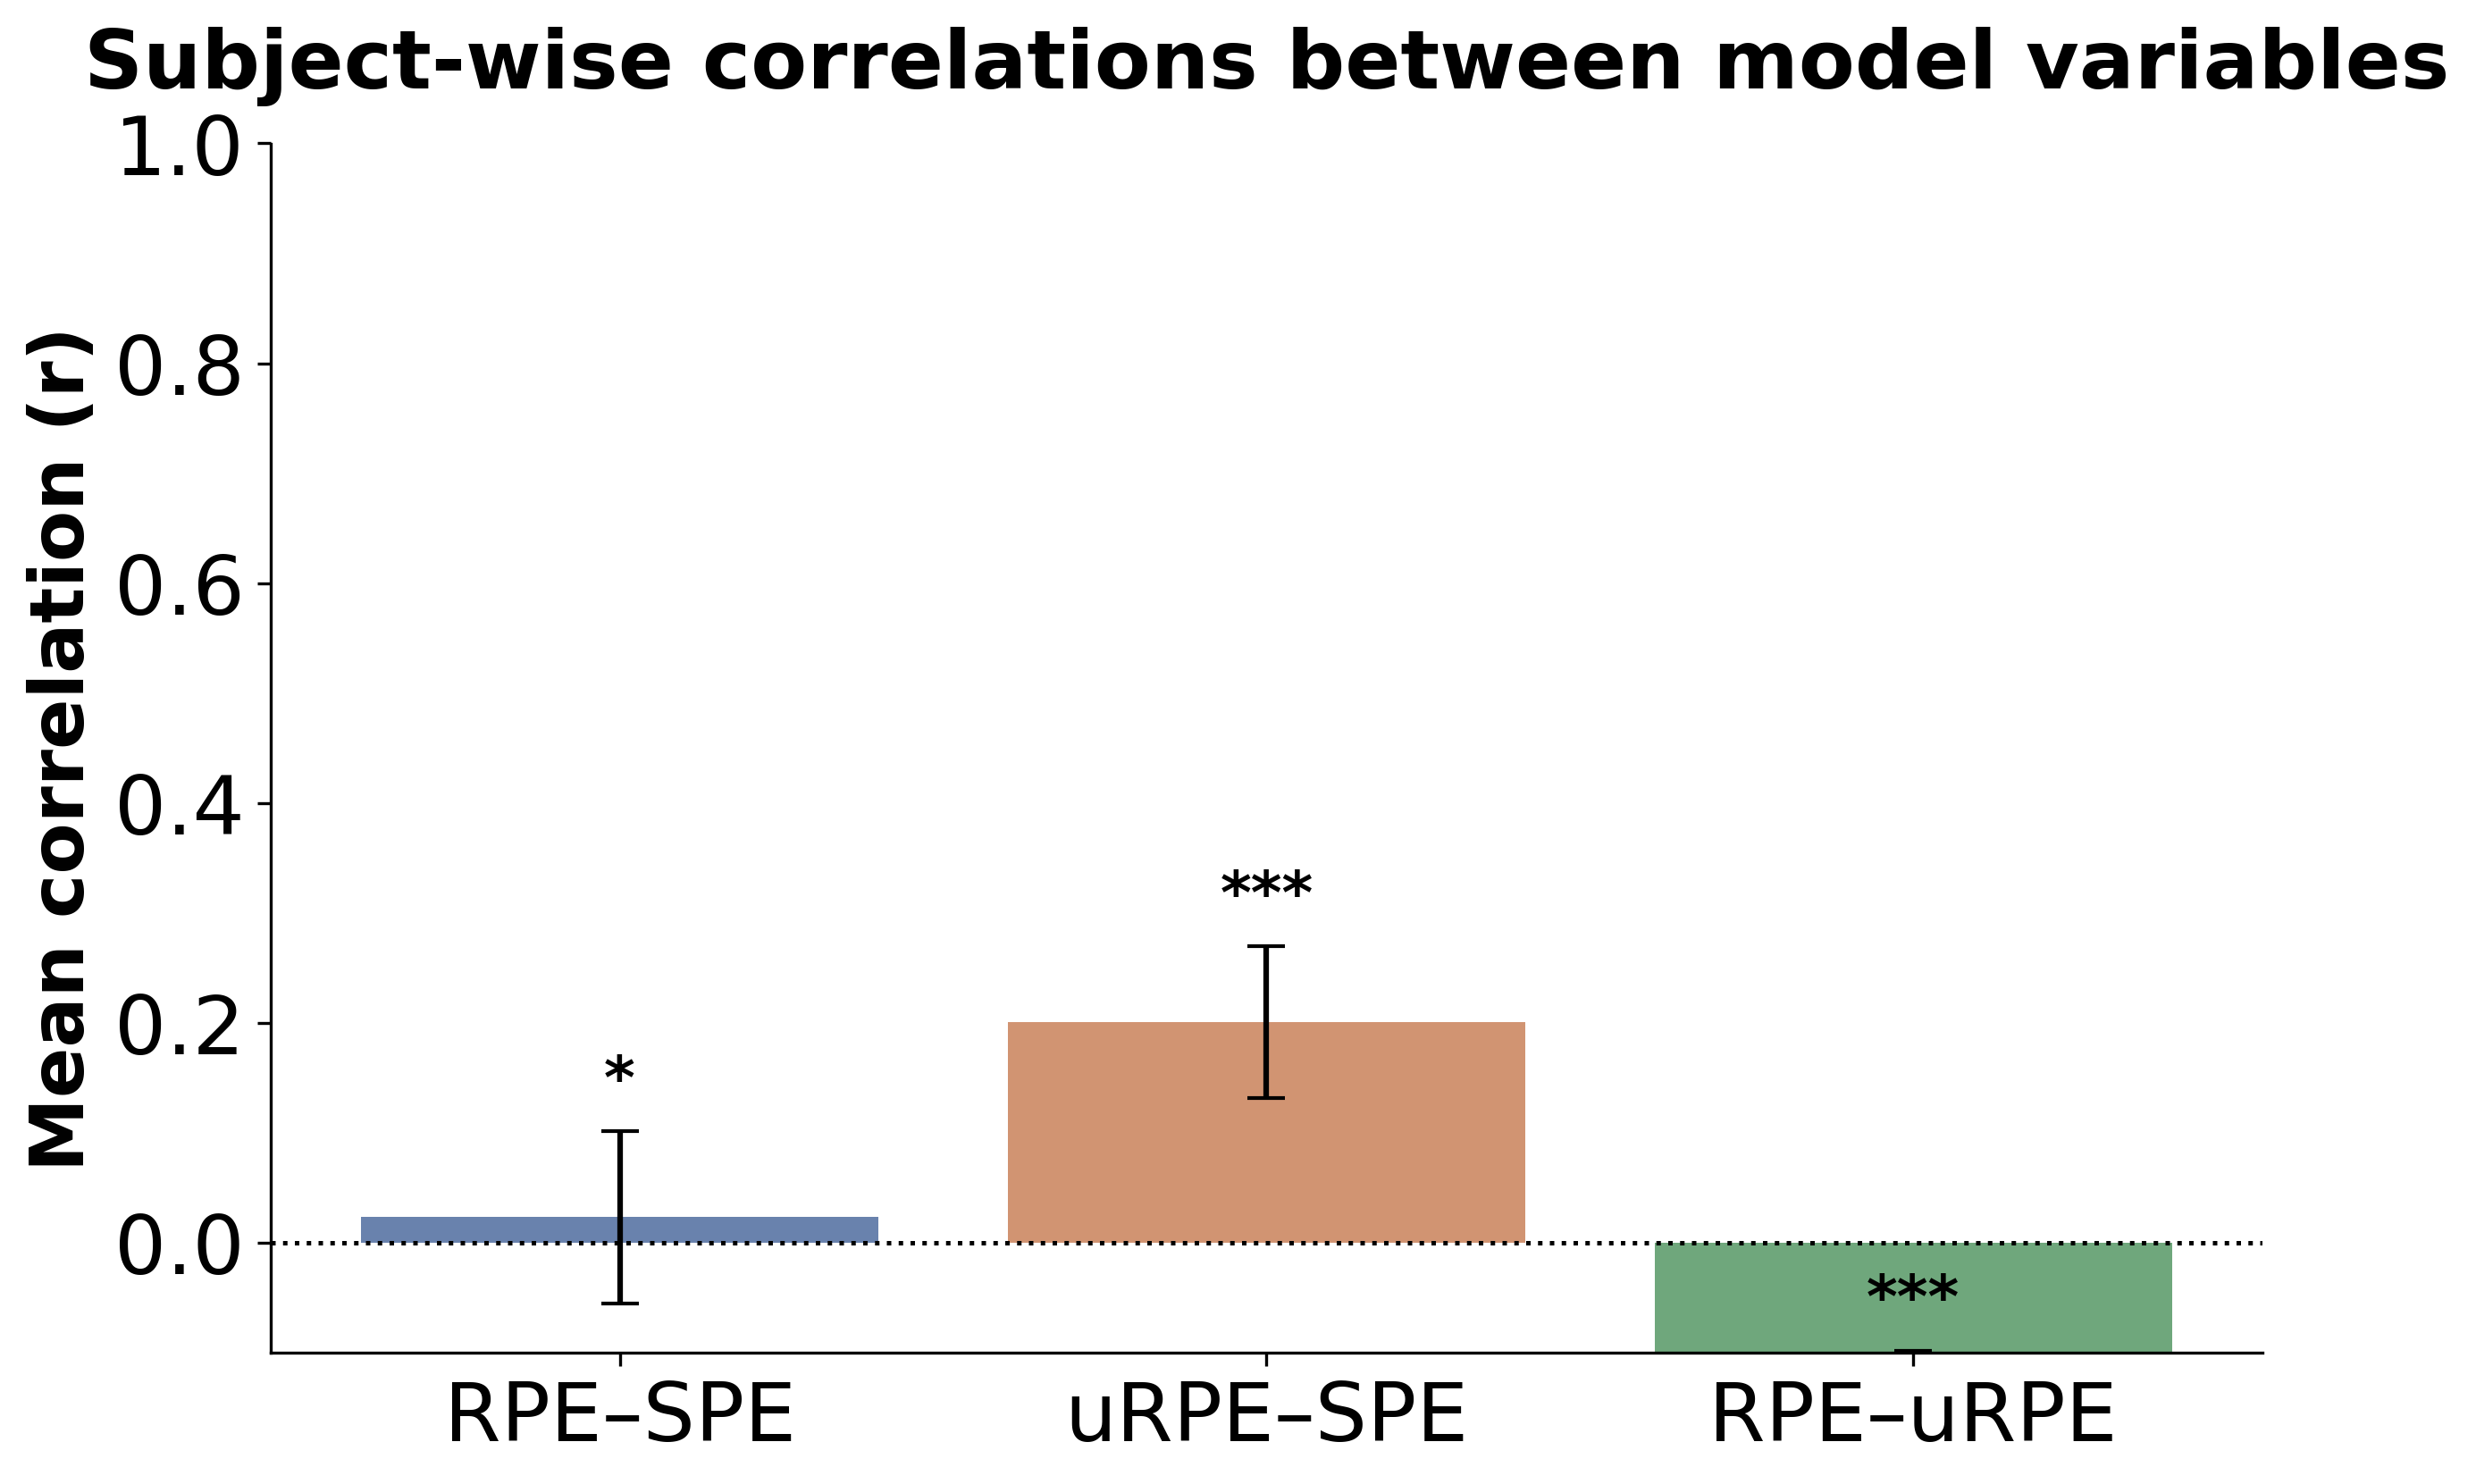

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_1samp

# ------------------------------------------------------------
# Helper function to compute subject-level mean correlations
# ------------------------------------------------------------
def compute_subjectwise_corr(df, subject_valid, x_col, y_col):
    records = []
    for subject in subject_valid:
        run_corrs = []
        for run in range(1, 7):
            subset = df.loc[
                (df.index.get_level_values('subject') == subject) &
                (df.index.get_level_values('runNumber') == run)
            ]
            if subset.empty:
                continue

            x_vals = subset[x_col].to_numpy()
            y_vals = subset[y_col].to_numpy()
            valid_mask = ~np.isnan(x_vals) & ~np.isnan(y_vals)

            if np.sum(valid_mask) > 1:
                r = np.corrcoef(x_vals[valid_mask], y_vals[valid_mask])[0, 1]
                run_corrs.append(r)

        if run_corrs:
            records.append({
                "subject": subject,
                "mean_r": np.nanmean(run_corrs)
            })

    corr_df = pd.DataFrame(records)
    corr_df["z"] = np.arctanh(corr_df["mean_r"])
    return corr_df


# ------------------------------------------------------------
# Compute correlations
# ------------------------------------------------------------
df["uRPE"] = np.abs(df["rpe"])

corr_rpe_spe = compute_subjectwise_corr(df, subject_valid, "spe", "rpe")
corr_urpe_spe = compute_subjectwise_corr(df, subject_valid, "spe", "uRPE")
corr_rpe_urpe = compute_subjectwise_corr(df, subject_valid, "rpe", "uRPE")

# ------------------------------------------------------------
# Run one-sample t-tests
# ------------------------------------------------------------
def summarize_corr(corr_df, label):
    t, p = ttest_1samp(corr_df["z"], 0, nan_policy="omit")
    mean_z = np.nanmean(corr_df["z"])
    mean_r = np.tanh(mean_z)
    std_r = np.nanstd(corr_df["mean_r"])
    n = len(corr_df)

    print("------------------------------------------------------------")
    print(f"{label} Correlation Summary")
    print("------------------------------------------------------------")
    print(corr_df.to_string(index=False, float_format="%.3f"))
    print("------------------------------------------------------------")
    print(f"Subjects: {n}")
    print(f"Mean r = {mean_r:.3f} ± {std_r:.3f}")
    print(f"T({n - 1}) = {t:.2f}, p = {p:.4f}")
    if p < 0.05:
        print("→ Significant correlation.")
    else:
        print("→ Not significantly different from 0 (ns).")
    print("------------------------------------------------------------\n")

    return {"label": label, "mean_r": mean_r, "std_r": std_r, "p": p}


summary_stats = []
summary_stats.append(summarize_corr(corr_rpe_spe, "RPE–SPE"))
summary_stats.append(summarize_corr(corr_urpe_spe, "uRPE–SPE"))
summary_stats.append(summarize_corr(corr_rpe_urpe, "RPE–uRPE"))

summary_df = pd.DataFrame(summary_stats)

# ------------------------------------------------------------
# Combined visualization
# ------------------------------------------------------------
plt.figure(figsize=(9, 6))
palette = ["#4C72B0", "#DD8452", "#55A868"]

sns.barplot(data=summary_df, x="label", y="mean_r", palette=palette, alpha=0.9, capsize=0.1)
plt.errorbar(
    x=np.arange(len(summary_df)),
    y=summary_df["mean_r"],
    yerr=summary_df["std_r"],
    fmt="none", ecolor="black", elinewidth=1.5, capsize=5
)

# Significance annotations
for i, row in summary_df.iterrows():
    y = row["mean_r"] + row["std_r"] + 0.02
    sig = "*" if row["p"] < 0.05 and row["p"] >= 0.001 else "***" if row["p"] < 0.001 else "n.s."
    plt.text(i, y, sig, ha="center", va="bottom", fontsize=16, weight="bold")

plt.axhline(0, color="black", linestyle=":", linewidth=1.2)
plt.ylabel("Mean correlation (r)", fontsize=20, weight="bold")
plt.xlabel("")
plt.title("Subject-wise correlations between model variables", fontsize=22, weight="bold", pad=15)
plt.ylim(-0.1, 1.0)
sns.despine()
plt.tight_layout()
plt.show()


In [28]:
def summarize_corr(corr_df, label):
    # Run one-sample t-test on Fisher z values
    t, p = ttest_1samp(corr_df["z"], 0, nan_policy="omit")
    mean_z = np.nanmean(corr_df["z"])
    mean_r = np.tanh(mean_z)
    std_r = np.nanstd(corr_df["mean_r"])
    n = len(corr_df)

    # Summary metrics
    mean_r2 = np.nanmean(corr_df["mean_r"] ** 2)
    std_r2 = np.nanstd(corr_df["mean_r"] ** 2)
    max_abs_r = np.nanmax(np.abs(corr_df["mean_r"]))

    # Clean, concise printout
    print("------------------------------------------------------------")
    print(f"{label} Correlation Summary")
    print("------------------------------------------------------------")
    print(f"Subjects: {n}")
    print(f"Mean r     = {mean_r:.3f} ± {std_r:.3f}")
    print(f"Mean r²    = {mean_r2:.3f} ± {std_r2:.3f}")
    print(f"Max |r|    = {max_abs_r:.3f}")
    print(f"T({n - 1}) = {t:.2f}, p = {p:.4f}")
    print("→", "Significant" if p < 0.05 else "Not significant (ns)")
    print("------------------------------------------------------------\n")

    return {
        "label": label,
        "mean_r": mean_r,
        "std_r": std_r,
        "mean_r2": mean_r2,
        "std_r2": std_r2,
        "max_abs_r": max_abs_r,
        "p": p
    }


In [29]:
summary_stats = []
summary_stats.append(summarize_corr(corr_rpe_spe, "RPE–SPE"))
summary_stats.append(summarize_corr(corr_urpe_spe, "uRPE–SPE"))
summary_stats.append(summarize_corr(corr_rpe_urpe, "RPE–uRPE"))


------------------------------------------------------------
RPE–SPE Correlation Summary
------------------------------------------------------------
Subjects: 52
Mean r     = 0.023 ± 0.078
Mean r²    = 0.007 ± 0.007
Max |r|    = 0.165
T(51) = 2.10, p = 0.0407
→ Significant
------------------------------------------------------------

------------------------------------------------------------
uRPE–SPE Correlation Summary
------------------------------------------------------------
Subjects: 52
Mean r     = 0.201 ± 0.069
Mean r²    = 0.045 ± 0.027
Max |r|    = 0.319
T(51) = 20.22, p = 0.0000
→ Significant
------------------------------------------------------------

------------------------------------------------------------
RPE–uRPE Correlation Summary
------------------------------------------------------------
Subjects: 52
Mean r     = -0.286 ± 0.187
Mean r²    = 0.110 ± 0.118
Max |r|    = 0.660
T(51) = -9.76, p = 0.0000
→ Significant
----------------------------------------------